In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df = df.dropna().reset_index(drop=True)

In [5]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


<Axes: xlabel='age', ylabel='Density'>

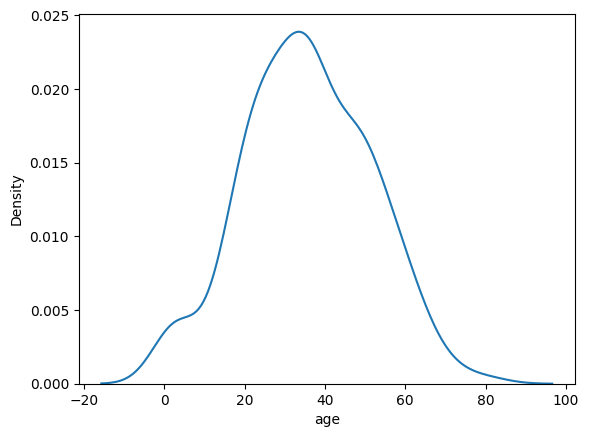

In [7]:
sns.kdeplot(x='age',data=df)

## Kurtosis

Kurtosis is a **statistical measure** that describes the **shape of a probability distribution's tails** relative to a normal distribution — specifically, how "heavy" or "light" the tails are, and how sharp or flat the peak is.

In simple terms: it tells you **how much of the data is in the tails (extreme values)** compared to a normal distribution.

---

### Formula

$$\text{Kurtosis} = \frac{\mu_4}{\sigma^4} = \frac{E[(X - \mu)^4]}{(\text{Var}(X))^2}$$

Where μ₄ is the **4th central moment** and σ is the standard deviation.

---

### Types of Kurtosis

| Type | Excess Kurtosis | Description |
|---|---|---|
| **Mesokurtic** | = 0 | Normal distribution (baseline) |
| **Leptokurtic** | > 0 | Heavy tails, sharp peak (more outliers) |
| **Platykurtic** | < 0 | Light tails, flat peak (fewer outliers) |

> **Excess Kurtosis** = Kurtosis − 3 (subtracts 3 to center the normal distribution at 0)

---

### Key Takeaway

- **High kurtosis** → data has more extreme outliers than a normal distribution
- **Low kurtosis** → data is more uniformly spread, fewer extreme values
- Widely used in **finance, quality control, and risk analysis** to understand the likelihood of extreme events

In [8]:
df['age'].kurtosis()

np.float64(-0.23094277355987147)

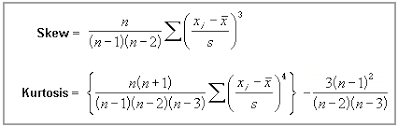

In [9]:
df.shape[0]

182

In [10]:
def N_values(N,start,end):
    denomiter = 1
    for i in range(start,end+1):
        denomiter = denomiter * (N - i)
    return denomiter

def Z_values(dataframe,column):
    result = []
    df_mean = df[column].mean()
    df_std = df[column].std()
    for i in range(dataframe.shape[0]):
        nor = dataframe[column][i] - df_mean
        z_value = (nor ** 4)/(df_std**4)
        result.append(float(z_value))
    return sum(result)

def my_kurtosis(df,column):
    N = df.shape[0]

    first_term = N*(N+1)/N_values(N,1,3)
    second_term = Z_values(df,column)
    third_term = (3 * ((N-1) ** 2)) /N_values(N,2,3)

    return (first_term * second_term) - third_term

In [11]:
my_kurtosis(df,'age') , df['age'].kurtosis()

(-0.23094277355987192, np.float64(-0.23094277355987147))

In [12]:
# def my_kurtosis(dataframe, column):
#     # Extract the series and drop missing values to ensure an accurate N count
#     series = dataframe[column].dropna()
#     N = series.shape[0]

#     # Kurtosis requires a sample size of at least 4
#     if N < 4:
#         raise ValueError("Kurtosis calculation requires at least 4 data points.")

#     # 1. Vectorized Z-value calculation
#     mean_val = series.mean()
#     std_val = series.std() # Pandas defaults to ddof=1 (sample std), which is correct
    
#     # Calculate the sum of all Z-values raised to the 4th power simultaneously 
#     z_sum = (((series - mean_val) / std_val) ** 4).sum()

#     # 2. Calculate the formula terms
#     first_term = (N * (N + 1)) / ((N - 1) * (N - 2) * (N - 3))
#     third_term = (3 * ((N - 1) ** 2)) / ((N - 2) * (N - 3))

#     return (first_term * z_sum) - third_term